# Self-Attention and Positional Encoding for IMDB Sentiment

This notebook begins with an embedding-plus-LSTM classifier, implements multi-head self-attention from its query, key, and value projections, and measures what changes when learned positional embeddings are added.

## What an embedding layer does

`torch.nn.Embedding` is a trainable lookup table. Each integer token ID selects one row, turning a discrete vocabulary item into a dense vector whose coordinates are learned through backpropagation. For a batch of shape `(batch, sequence)`, an embedding layer with dimension `d` returns `(batch, sequence, d)`.

The optional `padding_idx` marks a row that does not receive gradient updates. Keeping the padding row at zero makes it a neutral placeholder, although later sequence layers must still mask padded positions when pooling or computing attention. An embedding layer represents token identity; it does not encode token order by itself.

## Experiment design

The experiment reuses the repository's IMDB preprocessing and tokenization. Reviews that become identical after preprocessing and 128-token truncation are deduplicated before a seeded stratified 60/20/20 train/validation/test split. Vocabulary counts use training reviews only, and the test set remains outside checkpoint decisions.

All three models use 32-dimensional token embeddings, one sequence layer, dropout, one output logit, AdamW, stable binary cross-entropy, gradient clipping, and the same three-epoch budget. The compact 128-token limit keeps quadratic attention practical on the available CPU runtime.

The CLASS token is prepended at position 0. Therefore the instruction to extract the "final token embedding" is interpreted as extracting the final contextualized CLASS representation, not the representation at the last sequence position. This matches the purpose of a prepended classification token.

In [1]:
from collections import Counter
from itertools import chain
from pathlib import Path
import copy
import math
import os
import shutil
import subprocess
import sys
import time

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
import torch
from torch import nn

SEED = 42
MAX_REVIEW_TOKENS = 128
MAX_VOCABULARY_SIZE = 20_000
PAD_ID = 0
UNKNOWN_ID = 1
CLASS_ID = 2
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpu_name = "Not detected"
if shutil.which("nvidia-smi"):
    query = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    )
    gpu_name = query.stdout.strip()

current_path = Path.cwd().resolve()
repository_root = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / "phase-1-machine-learning-nlp").is_dir()
    ),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

phase_1 = repository_root / "phase-1-machine-learning-nlp"
part_02 = phase_1 / "02-preprocessing-tokenization"
sys.path.insert(0, str(part_02 / "src"))

from preprocessor import preprocess_text
from tokenizer import regex_tokenize

imdb_path = part_02 / "data" / "IMDB Dataset.csv"
if not imdb_path.exists():
    raise FileNotFoundError(
        "Download the IMDB 50K Reviews dataset and place 'IMDB Dataset.csv' in "
        f"{imdb_path.parent}. The CSV is intentionally ignored by Git."
    )

imdb = pd.read_csv(imdb_path).dropna(subset=["review", "sentiment"])
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})
if imdb["label"].isna().any():
    raise ValueError("Sentiment labels must be either 'negative' or 'positive'.")


def model_tokens(review):
    cleaned = preprocess_text(
        str(review), remove_stopwords=False, apply_stemming=False
    )
    return [
        token
        for token in regex_tokenize(cleaned)
        if token.isalpha() and len(token) >= 2
    ]


imdb["tokens"] = imdb["review"].map(model_tokens)
imdb["model_visible_text"] = (
    imdb["tokens"].str[:MAX_REVIEW_TOKENS].str.join(" ")
)
if imdb["model_visible_text"].eq("").any():
    raise ValueError("Preprocessing produced an empty review.")
if imdb.groupby("model_visible_text")["label"].nunique().gt(1).any():
    raise ValueError(
        "Reviews identical after preprocessing and truncation have conflicting labels."
    )

original_size = len(imdb)
imdb = imdb.drop_duplicates(subset="model_visible_text").reset_index(drop=True)
development, test = train_test_split(
    imdb,
    test_size=0.20,
    random_state=SEED,
    stratify=imdb["label"],
)
train, validation = train_test_split(
    development,
    test_size=0.25,
    random_state=SEED,
    stratify=development["label"],
)

split_frames = {"train": train, "validation": validation, "test": test}
for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    assert set(split_frames[left]["model_visible_text"]).isdisjoint(
        split_frames[right]["model_visible_text"]
    )

split_summary = pd.DataFrame(
    {
        "reviews": [len(train), len(validation), len(test)],
        "positive proportion": [
            train["label"].mean(),
            validation["label"].mean(),
            test["label"].mean(),
        ],
    },
    index=["train", "validation", "test"],
)

print(f"PyTorch: {torch.__version__}")
print(f"System GPU: {gpu_name}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")
print(f"Reviews retained: {len(imdb):,} ({original_size - len(imdb):,} duplicates removed)")
print("Model-visible review overlap across splits: 0")
display(split_summary.style.format({"positive proportion": "{:.4f}"}))

PyTorch: 2.13.0+cpu
System GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
PyTorch CUDA available: False
Selected device: cpu
Reviews retained: 49,572 (428 duplicates removed)
Model-visible review overlap across splits: 0


,reviews,positive proportion
train,29742,0.5019
validation,9915,0.5019
test,9915,0.5019


## Training-only vocabulary and CLASS sequences

Padding, unknown, and CLASS use IDs 0, 1, and 2. Word IDs begin at 3, and their frequency ranking is learned only from training reviews. The LSTM receives each 128-position review directly. Both attention models receive the same review with CLASS prepended, producing 129 positions. Padding masks prevent attention from assigning probability to padded keys.

In [2]:
token_counts = Counter(chain.from_iterable(train["tokens"]))
vocabulary_terms = [
    token
    for token, count in sorted(
        token_counts.items(), key=lambda item: (-item[1], item[0])
    )
    if count >= 2
][:(MAX_VOCABULARY_SIZE - 3)]
vocabulary = {
    token: index + 3 for index, token in enumerate(vocabulary_terms)
}


def encode_reviews(token_lists):
    encoded = np.full(
        (len(token_lists), MAX_REVIEW_TOKENS), PAD_ID, dtype=np.int32
    )
    lengths = np.empty(len(token_lists), dtype=np.int64)
    unknown_tokens = 0
    retained_tokens = 0
    for row, tokens in enumerate(token_lists):
        retained = tokens[:MAX_REVIEW_TOKENS]
        token_ids = [vocabulary.get(token, UNKNOWN_ID) for token in retained]
        encoded[row, :len(token_ids)] = token_ids
        lengths[row] = len(token_ids)
        unknown_tokens += sum(token_id == UNKNOWN_ID for token_id in token_ids)
        retained_tokens += len(token_ids)
    return encoded, lengths, unknown_tokens / retained_tokens


def prepend_class_token(review_ids):
    class_column = np.full((len(review_ids), 1), CLASS_ID, dtype=np.int32)
    return np.concatenate([class_column, review_ids], axis=1)


encoding_start = time.perf_counter()
train_ids, train_lengths, train_unknown_rate = encode_reviews(train["tokens"].tolist())
validation_ids, validation_lengths, validation_unknown_rate = encode_reviews(
    validation["tokens"].tolist()
)
test_ids, test_lengths, test_unknown_rate = encode_reviews(test["tokens"].tolist())
train_attention_ids = prepend_class_token(train_ids)
validation_attention_ids = prepend_class_token(validation_ids)
test_attention_ids = prepend_class_token(test_ids)

encoded_splits = {
    "train": train_ids,
    "validation": validation_ids,
    "test": test_ids,
}
encoded_rows = {
    name: {row.tobytes() for row in rows}
    for name, rows in encoded_splits.items()
}
for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    assert encoded_rows[left].isdisjoint(encoded_rows[right])
encoding_seconds = time.perf_counter() - encoding_start

train_labels = train["label"].to_numpy(dtype=np.float32)
validation_labels = validation["label"].to_numpy(dtype=np.float32)
test_labels = test["label"].to_numpy(dtype=np.float32)

sequence_summary = pd.DataFrame(
    {
        "mean retained length": [
            train_lengths.mean(), validation_lengths.mean(), test_lengths.mean()
        ],
        "truncated proportion": [
            np.mean(train["tokens"].str.len() > MAX_REVIEW_TOKENS),
            np.mean(validation["tokens"].str.len() > MAX_REVIEW_TOKENS),
            np.mean(test["tokens"].str.len() > MAX_REVIEW_TOKENS),
        ],
        "unknown-token rate": [
            train_unknown_rate, validation_unknown_rate, test_unknown_rate
        ],
    },
    index=["train", "validation", "test"],
)

print(f"Vocabulary size including special tokens: {len(vocabulary) + 3:,}")
print(f"LSTM training shape: {train_ids.shape}")
print(f"Attention training shape: {train_attention_ids.shape}")
print(f"Sequence encoding time: {encoding_seconds:.2f} seconds")
print("Encoded sequence overlap across splits: 0")
display(sequence_summary.style.format("{:.4f}"))
assert train_lengths.min() >= 1
assert np.all(train_attention_ids[:, 0] == CLASS_ID)

Vocabulary size including special tokens: 20,000
LSTM training shape: (29742, 128)
Attention training shape: (29742, 129)
Sequence encoding time: 1.03 seconds
Encoded sequence overlap across splits: 0


,mean retained length,truncated proportion,unknown-token rate
train,116.9340,0.6704,0.0394
validation,117.3164,0.6758,0.0421
test,116.9665,0.6659,0.0411


## LSTM, self-attention, and learned positions

The LSTM reads tokens sequentially and classifies from the final valid recurrent output. The attention layer projects every position into queries, keys, and values. For each head, scaled dot products compare every query with every key, a softmax produces attention weights, and the weighted values are concatenated and projected. A residual connection and layer normalization stabilize the representation.

Without positional information, the CLASS output can summarize token content but cannot distinguish permutations of the same tokens. The final model adds one learned position vector to each token embedding before the otherwise identical attention block. This exposes order but also introduces position-specific parameters that must be learned from the fixed training set.

In [3]:
EMBEDDING_DIMENSION = 32
ATTENTION_HEADS = 4
DROPOUT_RATE = 0.20


class SentimentLSTM(nn.Module):
    def __init__(self, vocabulary_size):
        super().__init__()
        self.embedding = nn.Embedding(
            vocabulary_size, EMBEDDING_DIMENSION, padding_idx=PAD_ID
        )
        self.lstm = nn.LSTM(
            input_size=EMBEDDING_DIMENSION,
            hidden_size=EMBEDDING_DIMENSION,
            batch_first=True,
        )
        self.dropout = nn.Dropout(DROPOUT_RATE)
        self.output = nn.Linear(EMBEDDING_DIMENSION, 1)
        nn.init.uniform_(self.embedding.weight, -0.05, 0.05)
        with torch.no_grad():
            self.embedding.weight[PAD_ID].zero_()
        for name, parameter in self.lstm.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(parameter)
            elif "weight_hh" in name:
                nn.init.orthogonal_(parameter)
            else:
                nn.init.zeros_(parameter)
                parameter.data[EMBEDDING_DIMENSION:2 * EMBEDDING_DIMENSION].fill_(1.0)
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        sequence_outputs, _ = self.lstm(embedded)
        batch_indices = torch.arange(token_ids.shape[0], device=token_ids.device)
        last_indices = lengths - 1
        representation = sequence_outputs[batch_indices, last_indices]
        return self.output(self.dropout(representation)).squeeze(1)


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embedding_dimension, heads, dropout):
        super().__init__()
        if embedding_dimension % heads != 0:
            raise ValueError("The embedding dimension must be divisible by the head count.")
        self.heads = heads
        self.head_dimension = embedding_dimension // heads
        self.query = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
        self.key = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
        self.value = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
        self.projection = nn.Linear(embedding_dimension, embedding_dimension)
        self.attention_dropout = nn.Dropout(dropout)
        self.residual_dropout = nn.Dropout(dropout)
        self.normalization = nn.LayerNorm(embedding_dimension)
        for layer in (self.query, self.key, self.value, self.projection):
            nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(self.projection.bias)

    def split_heads(self, tensor):
        batch, sequence, _ = tensor.shape
        return tensor.reshape(
            batch, sequence, self.heads, self.head_dimension
        ).transpose(1, 2)

    def forward(self, embedded, padding_mask):
        queries = self.split_heads(self.query(embedded))
        keys = self.split_heads(self.key(embedded))
        values = self.split_heads(self.value(embedded))
        scores = queries @ keys.transpose(-2, -1)
        scores = scores / math.sqrt(self.head_dimension)
        scores = scores.masked_fill(
            padding_mask[:, None, None, :],
            torch.finfo(scores.dtype).min,
        )
        weights = torch.softmax(scores, dim=-1)
        attended = self.attention_dropout(weights) @ values
        attended = attended.transpose(1, 2).contiguous().reshape(
            embedded.shape
        )
        projected = self.residual_dropout(self.projection(attended))
        return self.normalization(embedded + projected), weights


class SentimentSelfAttention(nn.Module):
    def __init__(self, vocabulary_size, use_positions):
        super().__init__()
        self.use_positions = use_positions
        self.embedding = nn.Embedding(
            vocabulary_size, EMBEDDING_DIMENSION, padding_idx=PAD_ID
        )
        self.attention = MultiHeadSelfAttention(
            EMBEDDING_DIMENSION, ATTENTION_HEADS, DROPOUT_RATE
        )
        self.dropout = nn.Dropout(DROPOUT_RATE)
        self.output = nn.Linear(EMBEDDING_DIMENSION, 1)
        nn.init.uniform_(self.embedding.weight, -0.05, 0.05)
        with torch.no_grad():
            self.embedding.weight[PAD_ID].zero_()
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)
        self.position_embedding = (
            nn.Embedding(MAX_REVIEW_TOKENS + 1, EMBEDDING_DIMENSION)
            if use_positions
            else None
        )
        if self.position_embedding is not None:
            nn.init.normal_(self.position_embedding.weight, mean=0.0, std=0.02)

    def forward(self, token_ids, lengths, return_attention=False):
        embedded = self.embedding(token_ids) * math.sqrt(EMBEDDING_DIMENSION)
        if self.position_embedding is not None:
            positions = torch.arange(token_ids.shape[1], device=token_ids.device)
            embedded = embedded + self.position_embedding(positions).unsqueeze(0)
        padding_mask = token_ids.eq(PAD_ID)
        contextualized, weights = self.attention(embedded, padding_mask)
        logits = self.output(self.dropout(contextualized[:, 0])).squeeze(1)
        if return_attention:
            return logits, weights
        return logits


vocabulary_size = len(vocabulary) + 3
torch.manual_seed(SEED)
attention_check_model = SentimentSelfAttention(
    vocabulary_size, use_positions=False
).to(device)
short_indices = np.argsort(train_lengths)[:4]
check_ids = torch.from_numpy(train_attention_ids[short_indices]).long().to(device)
check_lengths = torch.from_numpy(train_lengths[short_indices]).long().to(device)
attention_check_model.eval()
with torch.no_grad():
    check_logits, check_weights = attention_check_model(
        check_ids, check_lengths, return_attention=True
    )
padding_keys = check_ids.eq(PAD_ID)[:, None, None, :].expand_as(check_weights)
maximum_padding_weight = check_weights.masked_select(padding_keys).max().item()
weight_sum_error = (check_weights.sum(dim=-1) - 1.0).abs().max().item()

print(f"LSTM input positions: {train_ids.shape[1]}")
print(f"Attention input positions: {train_attention_ids.shape[1]}")
print(f"Attention output shape: {tuple(check_logits.shape)}")
print(f"Maximum attention weight on padding: {maximum_padding_weight:.8f}")
print(f"Maximum attention-row sum error: {weight_sum_error:.8f}")
assert check_logits.shape == (4,)
assert maximum_padding_weight == 0.0
assert weight_sum_error < 1e-6

LSTM input positions: 128
Attention input positions: 129
Attention output shape: (4,)
Maximum attention weight on padding: 0.00000000
Maximum attention-row sum error: 0.00000024


## Controlled training and validation checkpointing

Each model is trained from scratch with the same seed, batches, optimizer settings, and three epochs. Validation loss selects an in-memory checkpoint within each model. Gradient norms are checked for finiteness and clipped at 1.0. Test labels are not accessed during this stage.

In [4]:
BATCH_SIZE = 256
EPOCHS = 3
LEARNING_RATE = 1e-3
GRADIENT_NORM_CEILING = 1.0
loss_function = nn.BCEWithLogitsLoss()


def tensors_for_batch(token_ids, lengths, labels, indices):
    batch_ids = torch.from_numpy(token_ids[indices]).long().to(device)
    batch_lengths = torch.from_numpy(lengths[indices]).long().to(device)
    batch_labels = torch.from_numpy(labels[indices]).to(device)
    return batch_ids, batch_lengths, batch_labels


def evaluate_model(model, token_ids, lengths, labels):
    model.eval()
    total_loss = 0.0
    probabilities = []
    with torch.no_grad():
        for start in range(0, len(labels), BATCH_SIZE):
            indices = np.arange(start, min(start + BATCH_SIZE, len(labels)))
            batch_ids, batch_lengths, batch_labels = tensors_for_batch(
                token_ids, lengths, labels, indices
            )
            logits = model(batch_ids, batch_lengths)
            loss = loss_function(logits, batch_labels)
            if not torch.isfinite(loss):
                raise FloatingPointError("Evaluation produced a non-finite loss.")
            total_loss += loss.item() * len(indices)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
    return total_loss / len(labels), np.concatenate(probabilities)


def train_model(model, train_inputs, validation_inputs):
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4
    )
    history = []
    best_state = None
    best_epoch = None
    best_validation_loss = float("inf")
    maximum_gradient_norm = 0.0
    clipped_updates = 0
    start_time = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        shuffled_indices = np.random.default_rng(SEED + epoch).permutation(
            len(train_labels)
        )
        for start in range(0, len(train_labels), BATCH_SIZE):
            indices = shuffled_indices[start:start + BATCH_SIZE]
            batch_ids, batch_lengths, batch_labels = tensors_for_batch(
                train_inputs, train_lengths, train_labels, indices
            )
            optimizer.zero_grad()
            logits = model(batch_ids, batch_lengths)
            loss = loss_function(logits, batch_labels)
            if not torch.isfinite(loss):
                raise FloatingPointError("Training produced a non-finite loss.")
            loss.backward()
            gradient_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRADIENT_NORM_CEILING,
                error_if_nonfinite=True,
            )
            gradient_norm_value = float(gradient_norm)
            maximum_gradient_norm = max(
                maximum_gradient_norm, gradient_norm_value
            )
            clipped_updates += gradient_norm_value > GRADIENT_NORM_CEILING
            optimizer.step()
            epoch_loss += loss.item() * len(indices)

        train_loss = epoch_loss / len(train_labels)
        validation_loss, validation_probabilities = evaluate_model(
            model,
            validation_inputs,
            validation_lengths,
            validation_labels,
        )
        validation_predictions = (validation_probabilities >= 0.5).astype(int)
        row = {
            "epoch": epoch,
            "train loss": train_loss,
            "validation loss": validation_loss,
            "validation accuracy": accuracy_score(
                validation_labels, validation_predictions
            ),
            "validation F1": f1_score(
                validation_labels, validation_predictions
            ),
        }
        history.append(row)
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
        print(
            f"Epoch {epoch}/{EPOCHS} | train loss {train_loss:.4f} | "
            f"validation loss {validation_loss:.4f} | "
            f"validation accuracy {row['validation accuracy']:.4f} | "
            f"validation F1 {row['validation F1']:.4f}"
        )

    elapsed = time.perf_counter() - start_time
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history).set_index("epoch"), {
        "selected epoch": best_epoch,
        "seconds": elapsed,
        "maximum gradient norm": maximum_gradient_norm,
        "clipped updates": clipped_updates,
    }

In [5]:
model_builders = {
    "LSTM": lambda: SentimentLSTM(vocabulary_size),
    "Self-attention": lambda: SentimentSelfAttention(
        vocabulary_size, use_positions=False
    ),
    "Self-attention + positions": lambda: SentimentSelfAttention(
        vocabulary_size, use_positions=True
    ),
}
training_inputs = {
    "LSTM": (train_ids, validation_ids),
    "Self-attention": (train_attention_ids, validation_attention_ids),
    "Self-attention + positions": (
        train_attention_ids, validation_attention_ids
    ),
}
trained_models = {}
histories = {}
training_diagnostics = {}

for name, builder in model_builders.items():
    print(f"\n{name}")
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    model = builder().to(device)
    torch.manual_seed(SEED)
    train_input, validation_input = training_inputs[name]
    model, history, diagnostics = train_model(
        model, train_input, validation_input
    )
    trained_models[name] = model
    histories[name] = history
    training_diagnostics[name] = diagnostics
    print(
        f"Selected epoch {diagnostics['selected epoch']} | "
        f"{diagnostics['seconds']:.2f} seconds | "
        f"{sum(parameter.numel() for parameter in model.parameters()):,} parameters"
    )

validation_rows = []
for name, history in histories.items():
    selected_epoch = training_diagnostics[name]["selected epoch"]
    selected = history.loc[selected_epoch]
    validation_rows.append(
        {
            "model": name,
            "selected epoch": selected_epoch,
            "validation loss": selected["validation loss"],
            "validation accuracy": selected["validation accuracy"],
            "validation F1": selected["validation F1"],
            "seconds": training_diagnostics[name]["seconds"],
            "parameters": sum(
                parameter.numel()
                for parameter in trained_models[name].parameters()
            ),
            "maximum gradient norm": training_diagnostics[name][
                "maximum gradient norm"
            ],
            "clipped updates": training_diagnostics[name]["clipped updates"],
        }
    )

validation_comparison = pd.DataFrame(validation_rows).set_index("model")
display(validation_comparison.style.format({
    "validation loss": "{:.4f}",
    "validation accuracy": "{:.4f}",
    "validation F1": "{:.4f}",
    "seconds": "{:.2f}",
    "parameters": "{:,.0f}",
    "maximum gradient norm": "{:.4f}",
}))


LSTM


Epoch 1/3 | train loss 0.5713 | validation loss 0.4252 | validation accuracy 0.8227 | validation F1 0.8185


Epoch 2/3 | train loss 0.3430 | validation loss 0.4070 | validation accuracy 0.8242 | validation F1 0.8056


Epoch 3/3 | train loss 0.2504 | validation loss 0.4274 | validation accuracy 0.8413 | validation F1 0.8402
Selected epoch 2 | 20.11 seconds | 648,481 parameters

Self-attention


Epoch 1/3 | train loss 0.4847 | validation loss 0.3376 | validation accuracy 0.8510 | validation F1 0.8511


...

Epoch 3/3 | train loss 0.2157 | validation loss 0.3689 | validation accuracy 0.8499 | validation F1 0.8511
Selected epoch 1 | 204.79 seconds | 644,225 parameters

Self-attention + positions


Epoch 1/3 | train loss 0.4840 | validation loss 0.3352 | validation accuracy 0.8549 | validation F1 0.8552


Epoch 2/3 | train loss 0.2879 | validation loss 0.3476 | validation accuracy 0.8531 | validation F1 0.8482


Epoch 3/3 | train loss 0.2133 | validation loss 0.3759 | validation accuracy 0.8469 | validation F1 0.8450
Selected epoch 1 | 208.83 seconds | 648,353 parameters


,selected epoch,validation loss,validation accuracy,validation F1,seconds,parameters,maximum gradient norm,clipped updates
model,,,,,,,,
LSTM,2,0.4070,0.8242,0.8056,20.11,"648,481",23.0406,320
Self-attention,1,0.3376,0.8510,0.8511,204.79,"644,225",8.5332,298
Self-attention + positions,1,0.3352,0.8549,0.8552,208.83,"648,353",9.2734,301


## Learning curves and positional comparison

The histories show optimization under the equal short budget. The comparison between the two attention rows isolates learned positions: their sequence inputs, CLASS pooling, attention block, optimizer, and checkpoint rule are otherwise unchanged. Because the position-enabled model has extra parameters, any difference is conditional on this architecture and training budget rather than a universal claim about positional encoding.

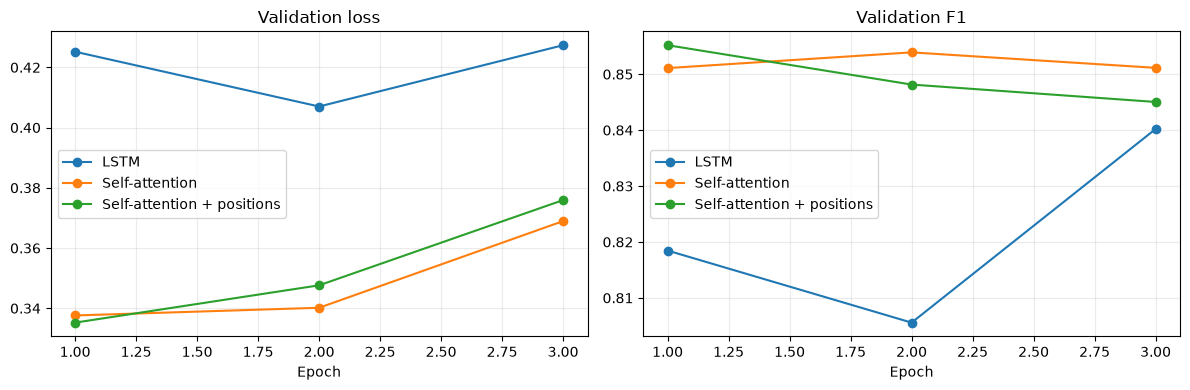

,positions minus no positions
validation loss change,-0.0024
validation accuracy change,+0.0038
validation F1 change,+0.0041


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, history in histories.items():
    history["validation loss"].plot(ax=axes[0], marker="o", label=name)
    history["validation F1"].plot(ax=axes[1], marker="o", label=name)
axes[0].set_title("Validation loss")
axes[1].set_title("Validation F1")
for axis in axes:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

attention_validation = validation_comparison.loc[
    ["Self-attention", "Self-attention + positions"]
]
position_delta = (
    attention_validation.loc["Self-attention + positions"]
    - attention_validation.loc["Self-attention"]
)
position_effect = pd.Series(
    {
        "validation loss change": position_delta["validation loss"],
        "validation accuracy change": position_delta["validation accuracy"],
        "validation F1 change": position_delta["validation F1"],
    },
    name="positions minus no positions",
).to_frame()
display(position_effect.style.format("{:+.4f}"))

## Held-out test evaluation

All model definitions and validation checkpoints are now fixed. Each retained checkpoint is evaluated once on the untouched test split. Accuracy and F1 summarize classification, precision and recall expose error balance, and ROC AUC measures probability ranking independently of the 0.5 threshold.

,loss,accuracy,precision,recall,F1,ROC AUC
model,,,,,,
LSTM,0.4115,0.8166,0.8967,0.7172,0.7970,0.9193
Self-attention,0.3501,0.8453,0.8478,0.8430,0.8454,0.9246
Self-attention + positions,0.3445,0.8485,0.8505,0.8471,0.8488,0.9270



LSTM

              precision    recall  f1-score   support

    negative     0.7629    0.9168    0.8328      4939
    positive     0.8967    0.7172    0.7970      4976

    accuracy                         0.8166      9915
   macro avg     0.8298    0.8170    0.8149      9915
weighted avg     0.8301    0.8166    0.8148      9915


Self-attention

              precision    recall  f1-score   support

    negative     0.8428    0.8475    0.8451      4939
    positive     0.8478    0.8430    0.8454      4976

    accuracy                         0.8453      9915
   macro avg     0.8453    0.8453    0.8453      9915
weighted avg     0.8453    0.8453    0.8453      9915


Self-attention + positions

              precision    recall  f1-score   support

    negative     0.8465    0.8500    0.8483      4939
    positive     0.8505    0.8471    0.8488      4976

    accuracy                         0.8485      9915
   macro avg     0.8485    0.8485    0.8485      9915
weighted avg     0.84

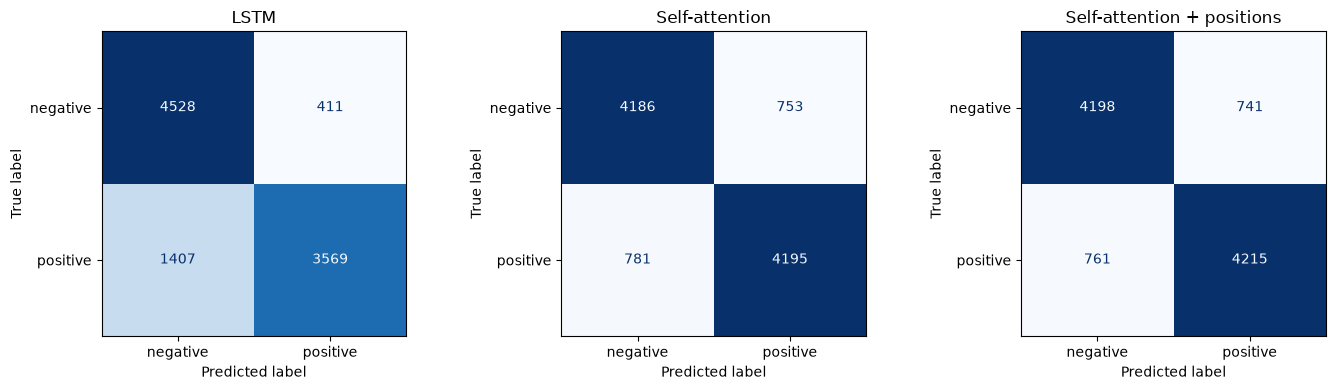

In [7]:
test_inputs = {
    "LSTM": test_ids,
    "Self-attention": test_attention_ids,
    "Self-attention + positions": test_attention_ids,
}
test_rows = []
test_predictions_by_model = {}

for name, model in trained_models.items():
    test_loss, test_probabilities = evaluate_model(
        model, test_inputs[name], test_lengths, test_labels
    )
    test_predictions = (test_probabilities >= 0.5).astype(int)
    test_predictions_by_model[name] = test_predictions
    test_rows.append(
        {
            "model": name,
            "loss": test_loss,
            "accuracy": accuracy_score(test_labels, test_predictions),
            "precision": precision_score(test_labels, test_predictions),
            "recall": recall_score(test_labels, test_predictions),
            "F1": f1_score(test_labels, test_predictions),
            "ROC AUC": roc_auc_score(test_labels, test_probabilities),
        }
    )

test_comparison = pd.DataFrame(test_rows).set_index("model")
display(test_comparison.style.format("{:.4f}"))

for name, predictions in test_predictions_by_model.items():
    print(f"\n{name}\n")
    print(classification_report(
        test_labels,
        predictions,
        target_names=["negative", "positive"],
        digits=4,
    ))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, (name, predictions) in zip(axes, test_predictions_by_model.items()):
    ConfusionMatrixDisplay.from_predictions(
        test_labels,
        predictions,
        display_labels=["negative", "positive"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(name)
plt.tight_layout()
plt.show()

assert np.isfinite(test_comparison.to_numpy()).all()
assert all(
    len(predictions) == len(test_labels)
    for predictions in test_predictions_by_model.values()
)

In [8]:
lstm_test = test_comparison.loc["LSTM"]
attention_test = test_comparison.loc["Self-attention"]
position_test = test_comparison.loc["Self-attention + positions"]
no_position_validation = validation_comparison.loc["Self-attention"]
position_validation = validation_comparison.loc["Self-attention + positions"]
total_training_seconds = sum(
    diagnostics["seconds"] for diagnostics in training_diagnostics.values()
)

if position_validation["validation loss"] < no_position_validation["validation loss"]:
    positional_conclusion = (
        "Learned positions improved the selected validation loss by "
        f"{no_position_validation['validation loss'] - position_validation['validation loss']:.4f}"
    )
else:
    positional_conclusion = (
        "Learned positions increased the selected validation loss by "
        f"{position_validation['validation loss'] - no_position_validation['validation loss']:.4f}"
    )

display(Markdown(
    f'''## Observations

The compact LSTM selected epoch **{training_diagnostics['LSTM']['selected epoch']}** and achieved held-out accuracy **{lstm_test['accuracy']:.4f}**, F1 **{lstm_test['F1']:.4f}**, and ROC AUC **{lstm_test['ROC AUC']:.4f}**. The CLASS-pooled self-attention model without positions achieved accuracy **{attention_test['accuracy']:.4f}**, F1 **{attention_test['F1']:.4f}**, and ROC AUC **{attention_test['ROC AUC']:.4f}**.

{positional_conclusion}. On the held-out test set, adding positions changed attention-model accuracy by **{position_test['accuracy'] - attention_test['accuracy']:+.4f}** and F1 by **{position_test['F1'] - attention_test['F1']:+.4f}**. This is the result of one compact, validation-checkpointed run. Positional information makes order available, but the short training budget does not guarantee that the model will use it better than content alone.

The training-only vocabulary left **{test_unknown_rate:.2%}** of retained test tokens unknown, and the 128-token cap truncated **{np.mean(test['tokens'].str.len() > MAX_REVIEW_TOKENS):.2%}** of test reviews. These limits reduce compute but discard context, especially for long reviews. A single attention block also has less sequential depth than the LSTM and far less capacity than a full Transformer encoder.

The detected system GPU was **{gpu_name}**, while PyTorch exposed CUDA as **{torch.cuda.is_available()}**. The experiment therefore used **{device}** with **{torch.get_num_threads()}** CPU threads. Training and validation for all three models took **{total_training_seconds:.2f} seconds**. No model checkpoints were written to disk.'''
))

## Observations

The compact LSTM selected epoch **2** and achieved held-out accuracy **0.8166**, F1 **0.7970**, and ROC AUC **0.9193**. The CLASS-pooled self-attention model without positions achieved accuracy **0.8453**, F1 **0.8454**, and ROC AUC **0.9246**.

Learned positions improved the selected validation loss by 0.0024. On the held-out test set, adding positions changed attention-model accuracy by **+0.0032** and F1 by **+0.0033**. This is the result of one compact, validation-checkpointed run. Positional information makes order available, but the short training budget does not guarantee that the model will use it better than content alone.

The training-only vocabulary left **4.11%** of retained test tokens unknown, and the 128-token cap truncated **66.59%** of test reviews. These limits reduce compute but discard context, especially for long reviews. A single attention block also has less sequential depth than the LSTM and far less capacity than a full Transformer encoder.

The detected system GPU was **NVIDIA GeForce RTX 3050 Ti Laptop GPU**, while PyTorch exposed CUDA as **False**. The experiment therefore used **cpu** with **8** CPU threads. Training and validation for all three models took **433.73 seconds**. No model checkpoints were written to disk.